In [1]:
import numpy as np
from scipy.interpolate import LinearNDInterpolator
import matplotlib as mpl
import matplotlib.pyplot as plt
import os

from discretize import TensorMesh
from discretize.utils import mkvc, active_from_xyz
from simpeg.utils import plot2Ddata, model_builder
from simpeg import maps
from simpeg.potential_fields import magnetics
from simpeg.potential_fields import gravity


write_output = False

import torch

In [2]:
# 1) Malla

dx = 18042.46/50
ncx = 50 
dy = 20729.81/50
ncy = 50 
dz = 8500/50
ncz = 50 



hx = [(dx, ncx)]
hy = [(dy, ncy)]
hz = [(dz, ncz)]
mesh = TensorMesh([hx, hy, hz], x0=[4609667.74, 1800295.19, -3500])

In [3]:
mesh

TensorMesh: 125,000 cells

                      MESH EXTENT             CELL WIDTH      FACTOR
  dir    nC        min           max         min       max      max
  ---   ---  ---------------------------  ------------------  ------
   x     50  4,609,667.74  4,627,710.20    360.85    360.85    1.00
   y     50  1,800,295.19  1,821,025.00    414.60    414.60    1.00
   z     50     -3,500.00      5,000.00    170.00    170.00    1.00

In [4]:
# 2) Modelo y receptores

model_npz = np.load("../../../../models/modelC/grav_modelC.npz")

model = model_npz["Grav_model"].astype(np.float32)
cell_centers = model_npz["cell_centers"].astype(np.float32)    # (nx, ny, nz), bool
dx = model_npz["dx"]               # (nx, ny, nz)
dy = model_npz["dy"]               # (nx, ny, nz)
dz = model_npz["dz"]               # (nx, ny, nz)

receiver_location = np.load("receivers_modelC.npy")

In [5]:
cell_centers.shape

(125000, 3)

In [6]:
receiver_location.shape

(676, 3)

In [7]:
np.unique(model)

array([-0.9 , -0.25,  0.  ,  0.1 ,  0.3 ,   nan], dtype=float32)

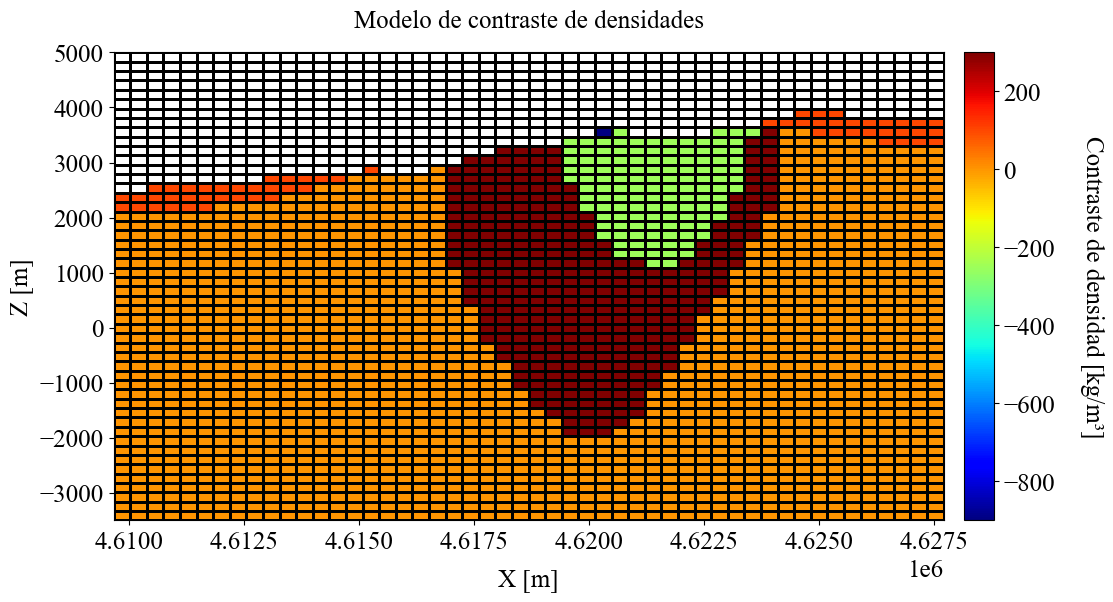

In [8]:
# 3) Visualización del modelo de contraste de densidad

fig = plt.figure(figsize=(10, 6))
mpl.rcParams["font.family"] = "Times New Roman"
ax1 = fig.add_axes([0.1, 0.12, 0.83, 0.78])


y_slice_coord = mesh.x0[1] + mesh.h[1].sum() / 2
m=model*1000

mesh.plot_slice(
    m,
    normal="Y",
    ax=ax1,
    #slice_loc=2058000,
    grid=True,
    clim=(np.nanmin(m), np.nanmax(m)),
    pcolor_opts={"cmap": "jet"},
)
ax1.set_title(f"Modelo de contraste de densidades", size=18, pad=18)
ax1.set_xlabel("X [m]", size=18, labelpad=10)
ax1.set_ylabel("Z [m]", size=18)
ax1.tick_params(axis="both", which="major", labelsize=18)
ax1.xaxis.get_offset_text().set_size(18)
ax1.yaxis.get_offset_text().set_size(18)

ax2 = fig.add_axes([0.95, 0.12, 0.03, 0.78])
norm = mpl.colors.Normalize(vmin=np.nanmin(m), vmax=np.nanmax(m))
cbar = mpl.colorbar.ColorbarBase(
    ax2, norm=norm, orientation="vertical", cmap=mpl.cm.jet
)
cbar.set_label("Contraste de densidad [kg/m³]", rotation=270, labelpad=35, size=18)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)

tick_fs = 18      
label_fs = 22     
title_fs = 22     

plt.show()

out_png = "ModelC_SimPEG.png"
fig.savefig(out_png, dpi=300, bbox_inches="tight", facecolor="white")

In [9]:
print(y_slice_coord)

1810660.095


In [10]:
# 4) Celdas activas

ind_active = ~np.isnan(model)       
n_active = ind_active.sum()

In [11]:
# 5) Mapeo del modelo

model_map = maps.IdentityMap(nP=n_active)

In [12]:
# 6) Survey de gravedad

components = ["gz"]

receiver_list = gravity.receivers.Point(receiver_location, components=components)
receiver_list = [receiver_list]


source_field = gravity.sources.SourceField(receiver_list=receiver_list)
survey = gravity.survey.Survey(source_field)

In [13]:
# 7) Simulación forward

simulation = gravity.simulation.Simulation3DIntegral(
    survey=survey,
    mesh=mesh,
    rhoMap=model_map,
    active_cells=ind_active,
    store_sensitivities="forward_only",
)

In [14]:
# 8) Modelo activo

model_active = model[~np.isnan(model)]
np.unique(model_active)


array([-0.9 , -0.25,  0.  ,  0.1 ,  0.3 ], dtype=float32)

In [15]:
model_active.shape

(95470,)

In [16]:
dpred = simulation.dpred(model_active)

In [17]:
dpred= -dpred

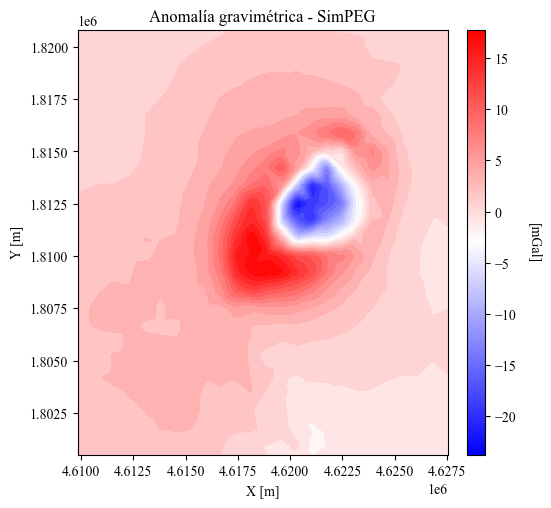

In [18]:
# 9) Plot Anomalía gravimétrica calculada con SimPEG

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(6, 5))

vmin = np.nanmin(dpred)
vmax = np.nanmax(dpred)

ax1 = fig.add_axes([0.1, 0.1, 0.80, 0.85])
plot2Ddata(
    receiver_list[0].locations,
    dpred,
    ax=ax1,
    ncontour=30,
    clim=(vmin, vmax),                
    contourOpts={"cmap": "bwr"},        
)

ax1.set_title("Anomalía gravimétrica - SimPEG")
ax1.set_xlabel("X [m]")
ax1.set_ylabel("Y [m]")

gap, cbar_w = 0.01, 0.03
ax2 = fig.add_axes([0.1 + 0.73 + gap, 0.1, cbar_w, 0.85])

norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
cbar = mpl.colorbar.ColorbarBase(ax2, norm=norm, cmap=mpl.cm.bwr, orientation="vertical")
cbar.set_label("[mGal]", rotation=270, labelpad=18)

plt.show()

out_png = "Modeling_modelC_SimPEG.png"
fig.savefig(out_png, dpi=300, bbox_inches="tight", facecolor="white")

In [19]:
# 11) Exportación de la respuesta calculada

obs_xyz_np = np.asarray(receiver_location, float)
resp_np    = np.asarray(dpred, float).reshape(-1)

if obs_xyz_np.ndim != 2 or obs_xyz_np.shape[1] != 3:
    raise ValueError(f"obs_xyz debe ser (nObs,3). Llegó: {obs_xyz_np.shape}")
if resp_np.size != obs_xyz_np.shape[0]:
    raise ValueError(f"Respuesta y obs no coinciden: {resp_np.size} vs {obs_xyz_np.shape[0]}")

out = np.column_stack([obs_xyz_np, resp_np])  # (nObs,4)

np.save("response_modelC_SimPEG.npy", out)

In [20]:
# 12) Carga de respuestas para comparación

simpeg = np.load("response_modelC_SimPEG.npy")
op = np.load("../Grav_modelC/response_modelC.npy")


In [21]:
re = dpred - op[:,-1]
np.max(re)

np.float64(0.008951676614660897)

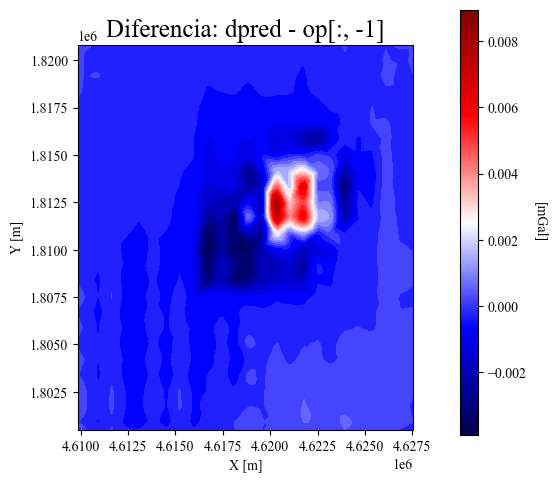

In [22]:
# 13) Mapa de diferencia entre SimPEG y el operador


import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl


difference = dpred - op[:, -1]
locs = receiver_list[0].locations 

vmin = np.nanmin(difference)
vmax = np.nanmax(difference)

fig, ax = plt.subplots(figsize=(6, 5))
plot2Ddata(locs, difference, ax=ax, ncontour=30, clim=(vmin, vmax), contourOpts={"cmap": "seismic"})

ax.set_title("Diferencia: dpred - op[:, -1]", fontsize=18)
ax.set_xlabel("X [m]")
ax.set_ylabel("Y [m]")

norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
cbar = mpl.colorbar.ColorbarBase(ax=fig.add_axes([0.87, 0.1, 0.03, 0.85]), norm=norm, orientation="vertical", cmap=mpl.cm.seismic)
cbar.set_label("[mGal]", rotation=270, labelpad=15)

plt.show()

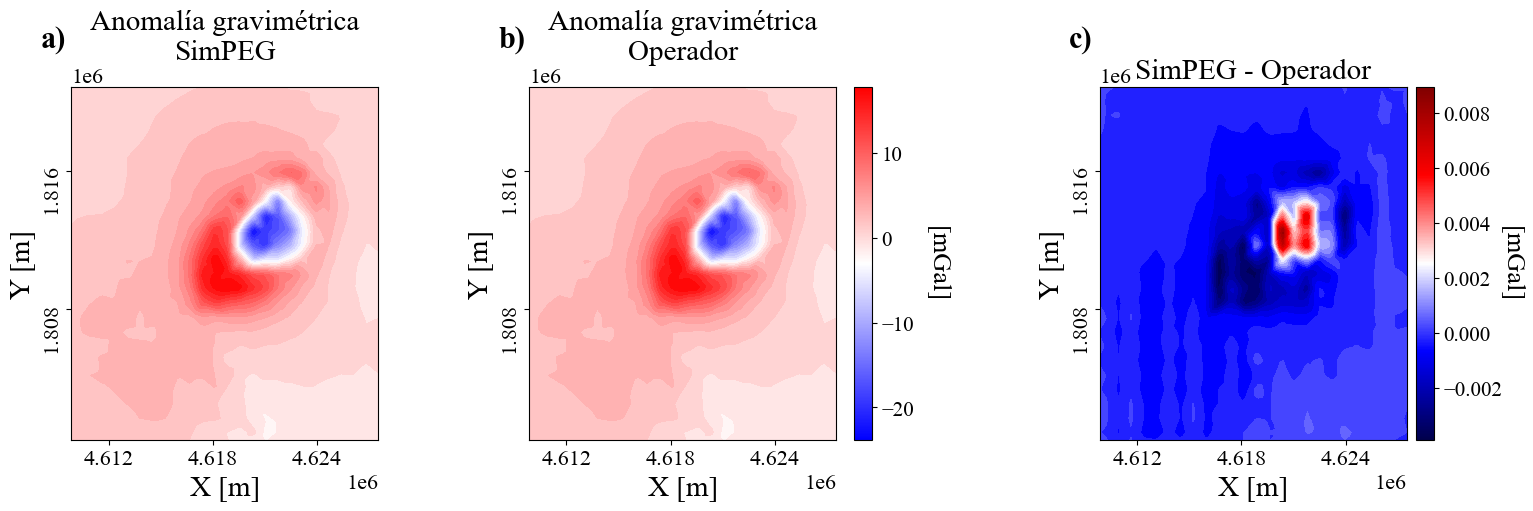

In [23]:
# 14) Comparación SimPEG vs operador

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

mpl.rcParams["font.family"] = "Times New Roman"

def extract_values(arr):
    """Return a (n,) vector of anomaly values from possible shapes."""
    arr = np.asarray(arr)
    if arr.ndim == 1:
        return arr.ravel()
    if arr.ndim == 2:
        if arr.shape[1] >= 4:   # (n,4) = XYZ + value
            return arr[:, -1].ravel()
        if arr.shape[1] == 1:   # (n,1)
            return arr[:, 0].ravel()
    raise ValueError(f"Unexpected array shape: {arr.shape}")

resp_op     = extract_values(op)
resp_simpeg = extract_values(dpred)

if resp_op.size != resp_simpeg.size:
    raise ValueError(f"Size mismatch: operator={resp_op.size} vs simpeg={resp_simpeg.size}")

dpred = resp_simpeg        
op_last = resp_op           
difference = dpred - op_last

locs = receiver_list[0].locations  

vmin = np.nanmin([resp_op, resp_simpeg])
vmax = np.nanmax([resp_op, resp_simpeg])

dvmin = np.nanmin(difference)
dvmax = np.nanmax(difference)

fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)

# (1) SimPEG
plot2Ddata(locs, resp_simpeg, ax=axes[0], ncontour=30, clim=(vmin, vmax),
           contourOpts={"cmap": "bwr"})
axes[0].set_title("Anomalía gravimétrica\nSimPEG", fontsize=18)
axes[0].set_xlabel("X [m]")
axes[0].set_ylabel("Y [m]")

# (2) Operador
plot2Ddata(locs, resp_op, ax=axes[1], ncontour=30, clim=(vmin, vmax),
           contourOpts={"cmap": "bwr"})
axes[1].set_title("Anomalía gravimétrica\nOperador", fontsize=18)
axes[1].set_xlabel("X [m]")
axes[1].set_ylabel("Y [m]")

# (3) Diferencia 
ax3 = axes[2]
plot2Ddata(locs, difference, ax=ax3, ncontour=30, clim=(dvmin, dvmax),
           contourOpts={"cmap": "seismic"})
ax3.set_title("SimPEG - Operador", fontsize=18, loc="center")
ax3.set_xlabel("X [m]")
ax3.set_ylabel("Y [m]")

for ax in axes:
    ax.xaxis.set_major_locator(mticker.MaxNLocator(3))
    ax.yaxis.set_major_locator(mticker.MaxNLocator(3))
    ax.tick_params(axis="both", labelsize=13)

for ax in axes:
    ax.ticklabel_format(style="sci", useOffset=True, axis="both")


norm12 = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
sm12 = mpl.cm.ScalarMappable(norm=norm12, cmap=mpl.cm.bwr)
sm12.set_array([])
cbar12 = fig.colorbar(sm12, ax=axes[:2], fraction=0.046, shrink=1, pad=0.02)
cbar12.set_label("[mGal]", rotation=270, labelpad=25, size=19)
cbar12.ax.tick_params(labelsize=15)

norm3 = mpl.colors.Normalize(vmin=dvmin, vmax=dvmax)
sm3 = mpl.cm.ScalarMappable(norm=norm3, cmap=mpl.cm.seismic)
sm3.set_array([])
cbar3 = fig.colorbar(sm3, ax=axes[2], fraction=0.046, shrink=1, pad=0.02)
cbar3.set_label("[mGal]", rotation=270, labelpad=15, size=19)
cbar3.ax.tick_params(labelsize=15)

tick_fs = 16
label_fs = 21
title_fs = 21
fs_offset_axes = 16
fs_offset_cbar = 16

for ax in axes:
    ax.tick_params(axis="x", which="major", labelsize=tick_fs, labelrotation=0)
    ax.tick_params(axis="y", which="major", labelsize=tick_fs, labelrotation=90)
    ax.set_xlabel("X [m]", fontsize=label_fs)
    ax.set_ylabel("Y [m]", fontsize=label_fs)
    ax.title.set_fontsize(title_fs)
    ax.xaxis.get_offset_text().set_fontsize(fs_offset_axes)
    ax.yaxis.get_offset_text().set_fontsize(fs_offset_cbar)


labels = ["a)", "b)", "c)"]
for ax, lab in zip(axes, labels):
    ax.text(-0.1, 1.09, lab, transform=ax.transAxes,
            ha="left", va="bottom", fontsize=22, fontweight="bold", clip_on=False)

plt.show()

out_png = "SimPEG-Operator.png"
fig.savefig(out_png, dpi=300, bbox_inches="tight", facecolor="white")

In [24]:
# 15) Datos para métricas

y_true=dpred
y_pred=op[:,-1]
resp_simpeg= np.min(dpred)
resp_simpeg= np.max(dpred)

resp_op= np.min(op[:,-1])
resp_op= np.max(op[:,-1])

In [25]:
# Error Medio Absoluto (MAE)

mae = np.mean(np.abs(y_true - y_pred))
print(mae)

0.00053249332745702


In [26]:
# Raíz del Error Cuadrático Medio (RMSE)

mae = np.mean(np.abs(y_true - y_pred))
print(mae)

0.00053249332745702


In [27]:
# Error Porcentual Medio Absoluto (MAPE)

eps = 1e-8
mape = 100 * np.mean(np.abs((y_true - y_pred) / (y_true + eps)))
print(mape)

0.03236028418916475


In [28]:
#PSNR

mse = np.mean((y_true - y_pred)**2)
Imax = np.max(y_true)
psnr = 10 * np.log10(Imax**2 / mse)
print(psnr)

84.70949616463602


In [29]:
#SSIM

from torchmetrics.image import StructuralSimilarityIndexMeasure
ssim_metric = StructuralSimilarityIndexMeasure(data_range=Imax - np.min(y_true))
y_true_COPY = torch.from_numpy(y_true.reshape(26, 26)).unsqueeze(0).unsqueeze(0)
y_pred_COPY = torch.from_numpy(y_pred.reshape(26, 26)).unsqueeze(0).unsqueeze(0)
print(y_true_COPY.shape)

print(ssim_metric(y_true_COPY, y_pred_COPY).item())

torch.Size([1, 1, 26, 26])
0.9999999403953552
